  RESTRICTED 3-IMPULSE STRATEGY
Optimal Apogee Radius (Rb): 16165.17 km
Total Delta V: 5.8671 km/s
  - Burn 1 (V, N):     [1.3436,  0.0000] km/s
  - Burn 2 (V, N):     [-1.3041, -2.9002] km/s
  - Burn 3 (V, N):     [-1.3436,  0.0000] km/s

  J2 TARGETING FOR GMAT
Total Time of Flight: 0.1457 days
Compensated target RAAN: 175.1551 deg


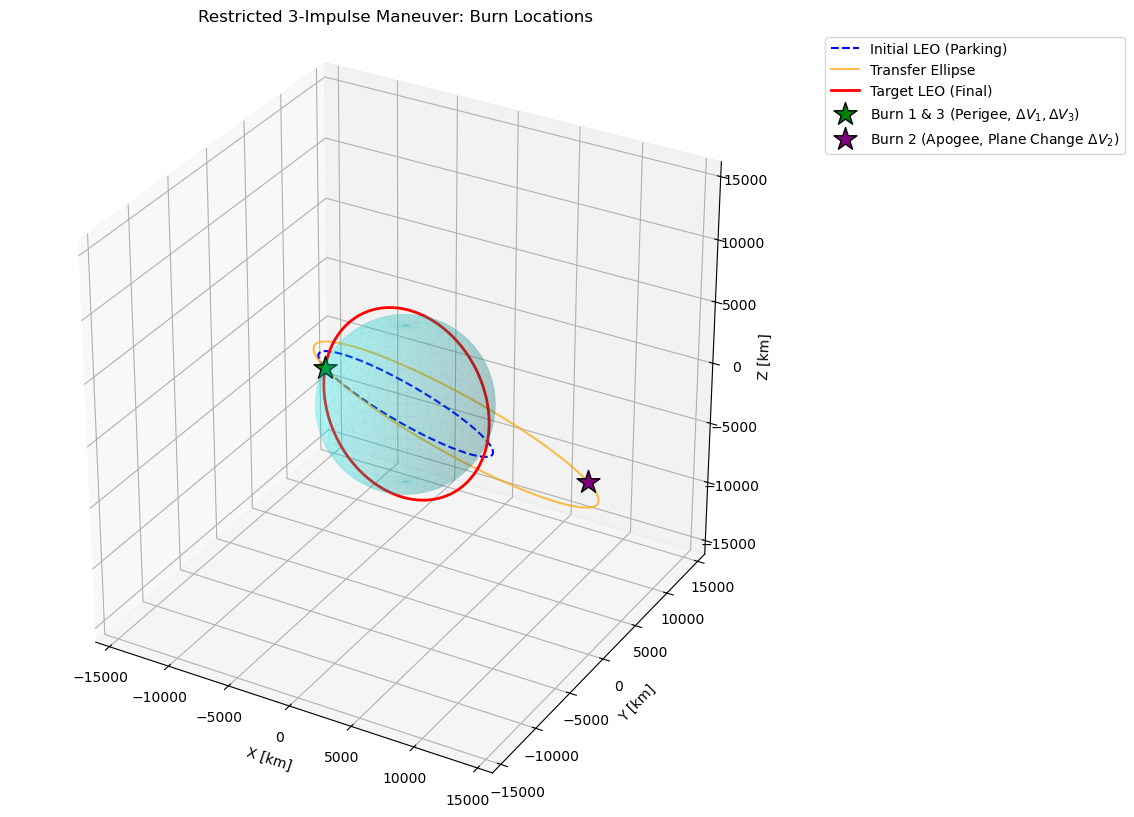

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar
import orekit
from orekit.pyhelpers import setup_orekit_curdir
from org.orekit.orbits import KeplerianOrbit, PositionAngleType
from org.orekit.frames import FramesFactory
from org.orekit.time import AbsoluteDate, TimeScalesFactory
from org.orekit.utils import Constants

# ==========================================
# 1. OREKIT ENVIRONMENT INITIALIZATION
# ==========================================
orekit.initVM()
setup_orekit_curdir('C:/Users/Simone/Downloads/orekit-data-main')

mu = Constants.WGS84_EARTH_MU
R_Earth = Constants.WGS84_EARTH_EQUATORIAL_RADIUS
J2 = Constants.WGS84_EARTH_C20 * -1.0 # In Orekit C20 is negative, J2 is positive

# ==========================================
# 2. CONSTANTS AND GEOMETRY
# ==========================================
h = 709000.0  # meters
R1 = R_Earth + h
Vc = np.sqrt(mu / R1)

inc1 = np.radians(50.0)
RAAN1 = np.radians(170.0)
inc2 = np.radians(98.2)
RAAN2 = np.radians(175.012)
DeltaOmega = RAAN2 - RAAN1

theta = np.arccos(np.cos(inc1)*np.cos(inc2) + np.sin(inc1)*np.sin(inc2)*np.cos(DeltaOmega))
u1 = np.arccos((-np.cos(inc2) + np.cos(theta)*np.cos(inc1)) / (np.sin(theta)*np.sin(inc1)))

TauWait_Secs = u1 * np.sqrt((R1**3)/mu)
TauWait_Days = TauWait_Secs / 86400.0

# ==========================================
# 3. RESTRICTED 3-IMPULSE OPTIMIZATION
# ==========================================
# Objective function to minimize (similar to fminbnd in MATLAB)
def Vtot_R3I(Rb):
    return 2*( np.sqrt(mu*(2/R1 - 2/(R1+Rb))) - np.sqrt(mu/R1) ) + \
           2*np.sqrt(mu*(2/Rb - 2/(R1+Rb))) * np.sin(theta/2)

# Minimum search between 1.01*R1 and 40*R1
res = minimize_scalar(Vtot_R3I, bounds=(1.01*R1, 40*R1), method='bounded')
Rb_R3I = res.x
DeltaVtot_R3I = res.fun

# Transfer ellipse parameters calculation
atr_R3I = (R1 + Rb_R3I) / 2
TauMan_R3I_Days = np.pi * np.sqrt((atr_R3I**3)/mu) / 86400.0

print("========================================================")
print("  RESTRICTED 3-IMPULSE STRATEGY")
print("========================================================")
print(f"Optimal Apogee Radius (Rb): {Rb_R3I/1000:.2f} km")
print(f"Total Delta V: {DeltaVtot_R3I/1000:.4f} km/s")

# Local velocities calculation for the transfer ellipse
Vp_R3I = np.sqrt(mu*(2/R1 - 1/atr_R3I))  # Velocity at perigee (maximum)
Va_R3I = np.sqrt(mu*(2/Rb_R3I - 1/atr_R3I)) # Velocity at apogee (minimum)

# Single Delta V (Magnitudes)
DV1_R3I = Vp_R3I - Vc
DV2_R3I = 2 * Va_R3I * np.sin(theta/2)
DV3_R3I = DV1_R3I # For the restricted strategy, burn 3 is symmetric to burn 1

# VNB components for GMAT (in m/s)
DV1_R3I_V = DV1_R3I
DV1_R3I_N = 0.0

DV2_R3I_V = Va_R3I * (np.cos(theta) - 1)
DV2_R3I_N = -Va_R3I * np.sin(theta)

DV3_R3I_V = -DV3_R3I
DV3_R3I_N = 0.0

print(f"  - Burn 1 (V, N):     [{DV1_R3I_V/1000:.4f},  {DV1_R3I_N/1000:.4f}] km/s")
print(f"  - Burn 2 (V, N):     [{DV2_R3I_V/1000:.4f}, {DV2_R3I_N/1000:.4f}] km/s")
print(f"  - Burn 3 (V, N):     [{DV3_R3I_V/1000:.4f},  {DV3_R3I_N/1000:.4f}] km/s")

# ==========================================
# 4. J2 TARGETING FOR GMAT
# ==========================================
RAANdot_rad_s = -(3/2) * J2 * (R_Earth/R1)**2 * np.sqrt(mu/(R1**3)) * np.cos(inc2)
RAANdot_deg_day = np.degrees(RAANdot_rad_s) * 86400.0

TimeOfFlight_R3I_Days = TauWait_Days + 2 * TauMan_R3I_Days
RAAN_target_R3I = (np.degrees(RAAN2) + RAANdot_deg_day * TimeOfFlight_R3I_Days) % 360

print("\n========================================================")
print("  J2 TARGETING FOR GMAT")
print("========================================================")
print(f"Total Time of Flight: {TimeOfFlight_R3I_Days:.4f} days")
print(f"Compensated target RAAN: {RAAN_target_R3I:.4f} deg")

# ==========================================
# 5. 3D GRAPHICS WITH MANEUVER POINTS (BURNS)
# ==========================================
inertial_frame = FramesFactory.getEME2000()
utc = TimeScalesFactory.getUTC()
initial_date = AbsoluteDate(2026, 6, 18, 12, 0, 0.0, utc) 

# Orbit 1: Initial LEO
orb1 = KeplerianOrbit(float(R1), 0.0, float(inc1), 0.0, float(RAAN1), float(u1), PositionAngleType.TRUE, inertial_frame, initial_date, float(mu))

# Orbit 2: Transfer Ellipse
e_trans = (Rb_R3I - R1) / (Rb_R3I + R1)
orb_trans = KeplerianOrbit(float(atr_R3I), float(e_trans), float(inc1), 0.0, float(RAAN1), float(u1), PositionAngleType.TRUE, inertial_frame, initial_date, float(mu))

# Orbit 3: Final LEO (Target)
orb_target = KeplerianOrbit(float(R1), 0.0, float(inc2), 0.0, float(RAAN2), float(u1), PositionAngleType.TRUE, inertial_frame, initial_date, float(mu))

# Continuous trajectory coordinates extraction
def get_orbit_coords(orbit, num_points=200):
    T = orbit.getKeplerianPeriod()
    times = np.linspace(0, T, num_points)
    x, y, z = [], [], []
    for dt in times:
        pos = orbit.shiftedBy(float(dt)).getPVCoordinates().getPosition()
        x.append(pos.getX()/1000); y.append(pos.getY()/1000); z.append(pos.getZ()/1000)
    return x, y, z

x1, y1, z1 = get_orbit_coords(orb1)
xt, yt, zt = get_orbit_coords(orb_trans, 400) 
x2, y2, z2 = get_orbit_coords(orb_target)

# --- EXACT BURN COORDINATES CALCULATION ---

# Burn 1 & Burn 3 (Occur at the same physical point: at perigee / maneuver node at t=0)
pos_b13 = orb1.getPVCoordinates().getPosition()
xb1 = pos_b13.getX() / 1000
yb1 = pos_b13.getY() / 1000
zb1 = pos_b13.getZ() / 1000

# Burn 2 (Occurs at the apogee of the transfer ellipse)
# We must propagate the ellipse forward by the "TauMan" time
dt_apogee = float(TauMan_R3I_Days * 86400.0) # Perigee -> Apogee flight time in seconds
pos_b2 = orb_trans.shiftedBy(dt_apogee).getPVCoordinates().getPosition()
xb2 = pos_b2.getX() / 1000
yb2 = pos_b2.getY() / 1000
zb2 = pos_b2.getZ() / 1000

# --- 3D PLOT SETUP ---
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Draw Earth
u_sph, v_sph = np.mgrid[0:2*np.pi:50j, 0:np.pi:25j]
x_e = (R_Earth/1000) * np.cos(u_sph) * np.sin(v_sph)
y_e = (R_Earth/1000) * np.sin(u_sph) * np.sin(v_sph)
z_e = (R_Earth/1000) * np.cos(v_sph)
ax.plot_surface(x_e, y_e, z_e, color='cyan', alpha=0.15, edgecolor='c', linewidth=0.1)

# Draw Trajectories
ax.plot(x1, y1, z1, label='Initial LEO (Parking)', color='blue', linestyle='--')
ax.plot(xt, yt, zt, label='Transfer Ellipse', color='orange', linewidth=1.5, alpha=0.7)
ax.plot(x2, y2, z2, label='Target LEO (Final)', color='red', linewidth=2)

# DRAW MARKERS FOR THE BURNS (Explosive stars)
ax.scatter([xb1], [yb1], [zb1], color='green', s=300, marker='*', edgecolor='black', label='Burn 1 & 3 (Perigee, $\Delta V_1, \Delta V_3$)', zorder=5)
ax.scatter([xb2], [yb2], [zb2], color='purple', s=300, marker='*', edgecolor='black', label='Burn 2 (Apogee, Plane Change $\Delta V_2$)', zorder=5)

# View setup
ax.set_box_aspect([1,1,1])
ax.set_xlim([-Rb_R3I/1000, Rb_R3I/1000])
ax.set_ylim([-Rb_R3I/1000, Rb_R3I/1000])
ax.set_zlim([-Rb_R3I/1000, Rb_R3I/1000])
ax.set_xlabel('X [km]'); ax.set_ylabel('Y [km]'); ax.set_zlabel('Z [km]')
ax.set_title('Restricted 3-Impulse Maneuver: Burn Locations')
ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1))

# Automatically save image
fig.savefig('restricted_3_impulse_burns_plot.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()